## Pipeline

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

In [ ]:
X = np.linspace(0, 10, 100)
e = np.random.random(100) #ruido gaussiano (normal estandar, media 0, variaza 1)
Y = np.sin(X) + e

<Axes: >

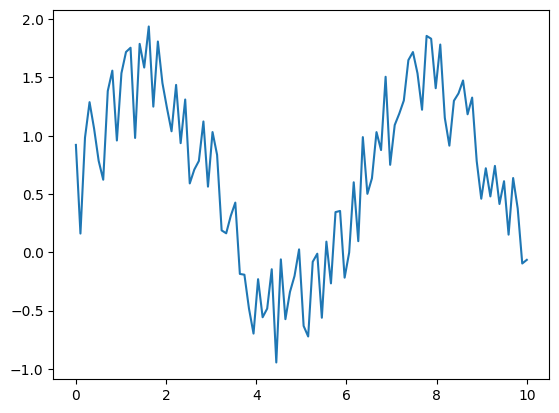

In [9]:
sns.lineplot(x=X,y=Y)

<Axes: >

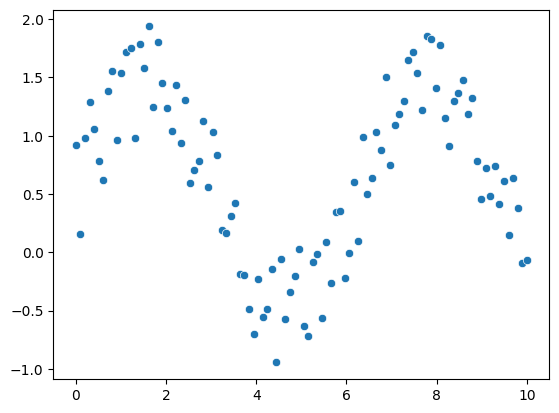

In [10]:
sns.scatterplot(x=X,y=Y)

In [16]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((80,), (20,), (80,), (20,))

In [36]:
X_train = X_train.reshape(-1, 1)
X_test  = X_test.reshape(-1, 1)

pipeline = Pipeline([
    ("poly", PolynomialFeatures(degree=10)),
    ("lr", LinearRegression())
])

score = cross_val_score(pipeline, X_train, Y_train, cv=5, scoring="neg_mean_squared_error")

score = -score
score.mean()

np.float64(0.1161346652684458)

<Axes: >

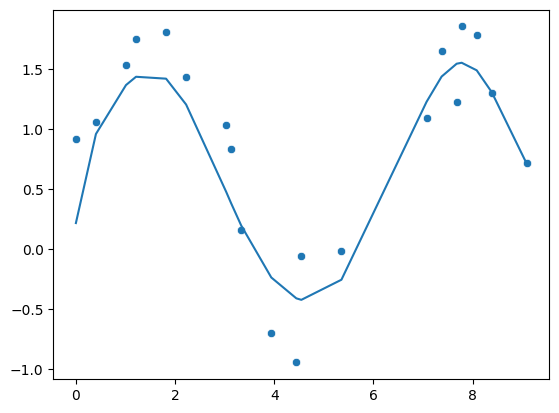

In [37]:
pipeline.fit(X_train, Y_train)
Y_pred = pipeline.predict(X_test)
sns.scatterplot(x=X_test.reshape(-1),y=Y_test)
sns.lineplot(x=X_test.reshape(-1),y=Y_pred)